# 14. Inference Pipeline — 실시간 위험도 추론 파이프라인

## 목적
새 환자 데이터가 들어오면 **매 시간 자동으로** 위험 등급을 산출하는 추론 파이프라인.  
기획서의 "매 시간마다 실시간 업데이트" 요구사항을 충족합니다.

## 입력
- `DATA/models/xgb_final_models.pkl`
- `DATA/processed/xgb_selected_features.csv`
- `DATA/processed/risk_thresholds.csv`
- 새 환자의 실시간 피처 데이터 (단일 행 또는 배치)

## 출력
- `DATA/models/risk_engine.pkl`
- `DATA/processed/feature_medians.csv`


In [9]:
from pathlib import Path
DATA_DIR      = Path('../data')
PROCESSED_DIR = DATA_DIR / 'processed'
MODEL_DIR     = Path('..') / 'models'

import pickle
import time
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

import xgboost as xgb
import shap

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

TARGET = 'composite_next_24h'

print('=== 14. Inference Pipeline — 실시간 위험도 추론 파이프라인 ===')


=== 14. Inference Pipeline — 실시간 위험도 추론 파이프라인 ===


## Step 1: SepsisRiskEngine 클래스 작성

> 단일 환자 1시간 데이터 추론 (`predict_single`),  
> 배치 추론 (`predict_batch`),  
> 특정 환자의 전체 시간 흐름 추론 (`predict_patient_timeline`)을 지원합니다.


In [10]:
print('Step 1: SepsisRiskEngine 클래스 작성')

class SepsisRiskEngine:
    """패혈증 위험도 추론 엔진.
    
    XGBoost 앙상블 모델을 사용해 매 시간 단위 위험 등급을 산출합니다.
    
    Parameters
    ----------
    model_path     : pkl 파일 경로 (models_final 리스트)
    feature_path   : xgb_selected_features.csv 경로
    threshold_path : risk_thresholds.csv 경로
    median_path    : feature_medians.csv 경로 (선택, 없으면 None)
    """

    ACTION_MAP = {
        'Low':    '정기 모니터링 유지',
        'Medium': '모니터링 강화 | 혈액배양 고려 | 바이탈 1시간마다 재확인',
        'High':   '즉시 담당의 통보 | 상급 처치 가능 여부 점검 | 전원 필요성 평가',
    }

    def __init__(self, model_path, feature_path, threshold_path, median_path=None):
        # ── 모델 로드 ──────────────────────────────────────────────────
        with open(model_path, 'rb') as f:
            self.models = pickle.load(f)

        # ── 피처 리스트 ────────────────────────────────────────────────
        # 모델 피처가 있으면 그걸 우선 사용
        model_features = None
        m = self.models[-1]
        if hasattr(m, 'feature_names') and m.feature_names:
            model_features = list(m.feature_names)
        elif hasattr(m, 'get_booster'):
            b = m.get_booster()
            if b.feature_names:
                model_features = list(b.feature_names)

        if model_features:
            self.features = model_features
        else:
            self.features = pd.read_csv(feature_path)['feature'].tolist()

        # ── Threshold 로드 ────────────────────────────────────────────
        thresh_df = pd.read_csv(threshold_path).set_index('thresh_name')['value']
        self.thresh_low  = float(thresh_df['thresh_low'])
        self.thresh_high = float(thresh_df['thresh_high'])

        # ── 누락 피처 대체값 (median) ─────────────────────────────────
        if median_path is not None and Path(median_path).exists():
            med_df = pd.read_csv(median_path).set_index('feature')['median']
            self.feature_medians = med_df.to_dict()
        else:
            self.feature_medians = {feat: 0.0 for feat in self.features}

        # ── SHAP explainer (마지막 fold 모델 사용) ────────────────────
        explainer_model = self.models[-1].get_booster() if hasattr(self.models[-1], 'get_booster') else self.models[-1]
        self._explainer = shap.TreeExplainer(explainer_model)

        print(f'  모델 fold 수  : {len(self.models)}')
        print(f'  사용 피처 수  : {len(self.features)}')
        print(f'  thresh_low   : {self.thresh_low:.4f}')
        print(f'  thresh_high  : {self.thresh_high:.4f}')

    # ── 내부 유틸 ──────────────────────────────────────────────────────
    def _fill_missing(self, df: pd.DataFrame) -> pd.DataFrame:
        """누락 피처를 학습 데이터 median으로 대체."""
        missing = [f for f in self.features if f not in df.columns]
        if missing:
            import sys
            print(f'  [WARNING] 누락 피처 {len(missing)}개 → median 대체: {missing[:5]}...'
                  if len(missing) > 5 else
                  f'  [WARNING] 누락 피처 {len(missing)}개 → median 대체: {missing}',
                  file=sys.stderr)
            for f in missing:
                df[f] = self.feature_medians.get(f, 0.0)
        return df[self.features]

    def _prob_to_level(self, prob):
        """확률 → Low / Medium / High 변환 (스칼라 & 배열 지원)."""
        scalar = np.isscalar(prob)
        arr = np.atleast_1d(np.asarray(prob, dtype=float))
        result = np.where(arr >= self.thresh_high, 'High',
                 np.where(arr >= self.thresh_low,  'Medium', 'Low'))
        return result[0] if scalar else result

    def _shap_top3(self, X_df: pd.DataFrame):
        """각 행의 SHAP Top-3 기여 요인 반환."""
        shap_vals = self._explainer.shap_values(X_df)   # (n, n_features)
        feat_arr  = np.array(self.features)
        abs_shap  = np.abs(shap_vals)
        top3_idx  = np.argsort(abs_shap, axis=1)[:, -3:][:, ::-1]

        results = []
        for i in range(len(X_df)):
            factors = []
            for col_idx in top3_idx[i]:
                factors.append({
                    'feature'  : feat_arr[col_idx],
                    'direction': '↑' if shap_vals[i, col_idx] > 0 else '↓',
                    'shap'     : float(shap_vals[i, col_idx]),
                })
            results.append(factors)
        return results

    def _ensemble_predict(self, dmat) -> np.ndarray:
        """모든 fold 모델의 예측값 평균 (앙상블)."""
        preds = np.stack([m.predict(dmat) for m in self.models], axis=0)
        return preds.mean(axis=0)

    # ── 공개 API ──────────────────────────────────────────────────────
    def predict_single(self, feature_dict: dict) -> dict:
        """단일 환자 1시간 데이터 → 위험 등급 + 기여 요인."""
        df_row = pd.DataFrame([feature_dict])
        X = self._fill_missing(df_row)
        dmat = xgb.DMatrix(X.values, feature_names=self.features)
        prob = float(self._ensemble_predict(dmat)[0])
        level = str(self._prob_to_level(prob))
        top3 = self._shap_top3(X)[0]
        return {
            'risk_prob'     : prob,
            'risk_level'    : level,
            'action_message': self.ACTION_MAP[level],
            'top_factors'   : top3,
        }

    def predict_batch(self, df: pd.DataFrame) -> pd.DataFrame:
        """여러 행 배치 추론 → risk_level / action_message / top_factors 컬럼 추가."""
        df_in = df.copy()
        X = self._fill_missing(df_in)
        dmat = xgb.DMatrix(X.values, feature_names=self.features)
        probs  = self._ensemble_predict(dmat)
        levels = self._prob_to_level(probs)
        top3s  = self._shap_top3(X)

        df_out = df.copy()
        df_out['risk_prob']      = probs
        df_out['risk_level']     = levels
        df_out['action_message'] = [self.ACTION_MAP[l] for l in levels]

        # Top-3 피처 컬럼 추가
        for rank in range(1, 4):
            df_out[f'top{rank}_feature']   = [f[rank-1]['feature']   for f in top3s]
            df_out[f'top{rank}_direction'] = [f[rank-1]['direction'] for f in top3s]
            df_out[f'top{rank}_shap']      = [f[rank-1]['shap']      for f in top3s]
        return df_out

    def predict_patient_timeline(self, stay_id, df_all: pd.DataFrame) -> pd.DataFrame:
        """특정 환자의 전체 시간 흐름 추론 → 시간별 위험 등급 변화."""
        df_pt = df_all[df_all['stay_id'] == stay_id].copy()
        if df_pt.empty:
            raise ValueError(f'stay_id={stay_id} 를 찾을 수 없습니다.')
        df_pt = df_pt.sort_values('observation_hour')
        return self.predict_batch(df_pt)


print('✔ SepsisRiskEngine 클래스 정의 완료')


Step 1: SepsisRiskEngine 클래스 작성
✔ SepsisRiskEngine 클래스 정의 완료


## Step 2: 누락 피처 처리 로직 & feature_medians.csv 저장

> 실시간 환경에서 일부 피처가 없을 수 있습니다.  
> 누락 피처는 학습 데이터(features_final.csv)의 median으로 대체합니다.


In [11]:
print('Step 2: 누락 피처 처리 로직 & feature_medians.csv 저장')

import pickle

# features/labels 로드
df_features = pd.read_csv(PROCESSED_DIR / 'features_final.csv')
df_labels   = pd.read_csv(PROCESSED_DIR / 'labels_final.csv')

print(f'features_final: {len(df_features):,} rows')
print(f'labels_final  : {len(df_labels):,} rows')

assert len(df_features) == len(df_labels), 'features/labels row mismatch'

# 모델 피처 리스트 로드 (모델 기준 우선)
with open(MODEL_DIR / 'xgb_final_models.pkl', 'rb') as f:
    models = pickle.load(f)

def _get_model_features(models):
    m = models[-1]
    if hasattr(m, 'feature_names') and m.feature_names:
        return list(m.feature_names)
    if hasattr(m, 'get_booster'):
        b = m.get_booster()
        if b.feature_names:
            return list(b.feature_names)
    return None

model_features = _get_model_features(models)
if not model_features:
    model_features = pd.read_csv(PROCESSED_DIR / 'xgb_selected_features.csv')['feature'].tolist()

selected_features = model_features
print(f'모델 피처: {len(model_features)}개')

# 필요 시 피처 리스트 저장 (모델 기준)
pd.DataFrame({'feature': model_features}).to_csv(PROCESSED_DIR / 'xgb_model_features.csv', index=False)

# df_all: 추론용 전체 데이터 (stay_id/observation_hour 포함)
df_all = df_features.copy()
if 'stay_id' in df_labels.columns:
    df_all['stay_id'] = df_labels['stay_id'].values
if 'observation_hour' in df_labels.columns and 'observation_hour' not in df_all.columns:
    df_all['observation_hour'] = df_labels['observation_hour'].values

# 학습 데이터 기준 median 계산
feat_avail = [f for f in model_features if f in df_features.columns]
medians    = df_features[feat_avail].median()

# 피처가 학습 데이터에 없는 경우 0으로 처리
median_dict = {}
for feat in model_features:
    median_dict[feat] = float(medians[feat]) if feat in medians.index else 0.0

# feature_medians.csv 저장
df_medians = pd.DataFrame([
    {'feature': feat, 'median': val} for feat, val in median_dict.items()
])
df_medians.to_csv(PROCESSED_DIR / 'feature_medians.csv', index=False)

print(f'\n✔ feature_medians.csv 저장: {len(df_medians)}개 피처')
print(df_medians.head(10).to_string(index=False))


Step 2: 누락 피처 처리 로직 & feature_medians.csv 저장
features_final: 158,985 rows
labels_final  : 158,985 rows
모델 피처: 51개

✔ feature_medians.csv 저장: 51개 피처
   feature     median
        hr  86.000000
        rr  19.500000
      spo2  94.000000
       sbp 107.000000
       dbp  55.000000
       mbp  70.000000
      temp  36.833333
    hr_max  94.000000
    rr_max  24.000000
creatinine   1.000000


## Step 3: 동작 테스트 — 단일 환자 시간별 위험 등급 변화

> `risk_scored.csv`에서 High 등급 환자 1명 선택 후 `predict_patient_timeline()` 실행.


Step 3: 동작 테스트 — 단일 환자
  모델 fold 수  : 5
  사용 피처 수  : 51
  thresh_low   : 0.1009
  thresh_high  : 0.2018

테스트 환자: stay_id = 30005474
타임라인 rows: 40
 stay_id  observation_hour  risk_prob risk_level top1_feature top1_direction     top2_feature top2_direction
30005474                 6   0.251977       High   sofa_total              ↓ observation_hour              ↑
30005474                 7   0.181556     Medium   sofa_total              ↓  gcs_total_slope              ↓
30005474                 8   0.164950     Medium   sofa_total              ↓       creatinine              ↓
30005474                 9   0.131482     Medium   sofa_total              ↓       creatinine              ↓
30005474                10   0.132127     Medium   sofa_total              ↓       creatinine              ↓
30005474                11   0.134017     Medium   sofa_total              ↓       creatinine              ↓
30005474                12   0.157491     Medium   sofa_total              ↓       creatini

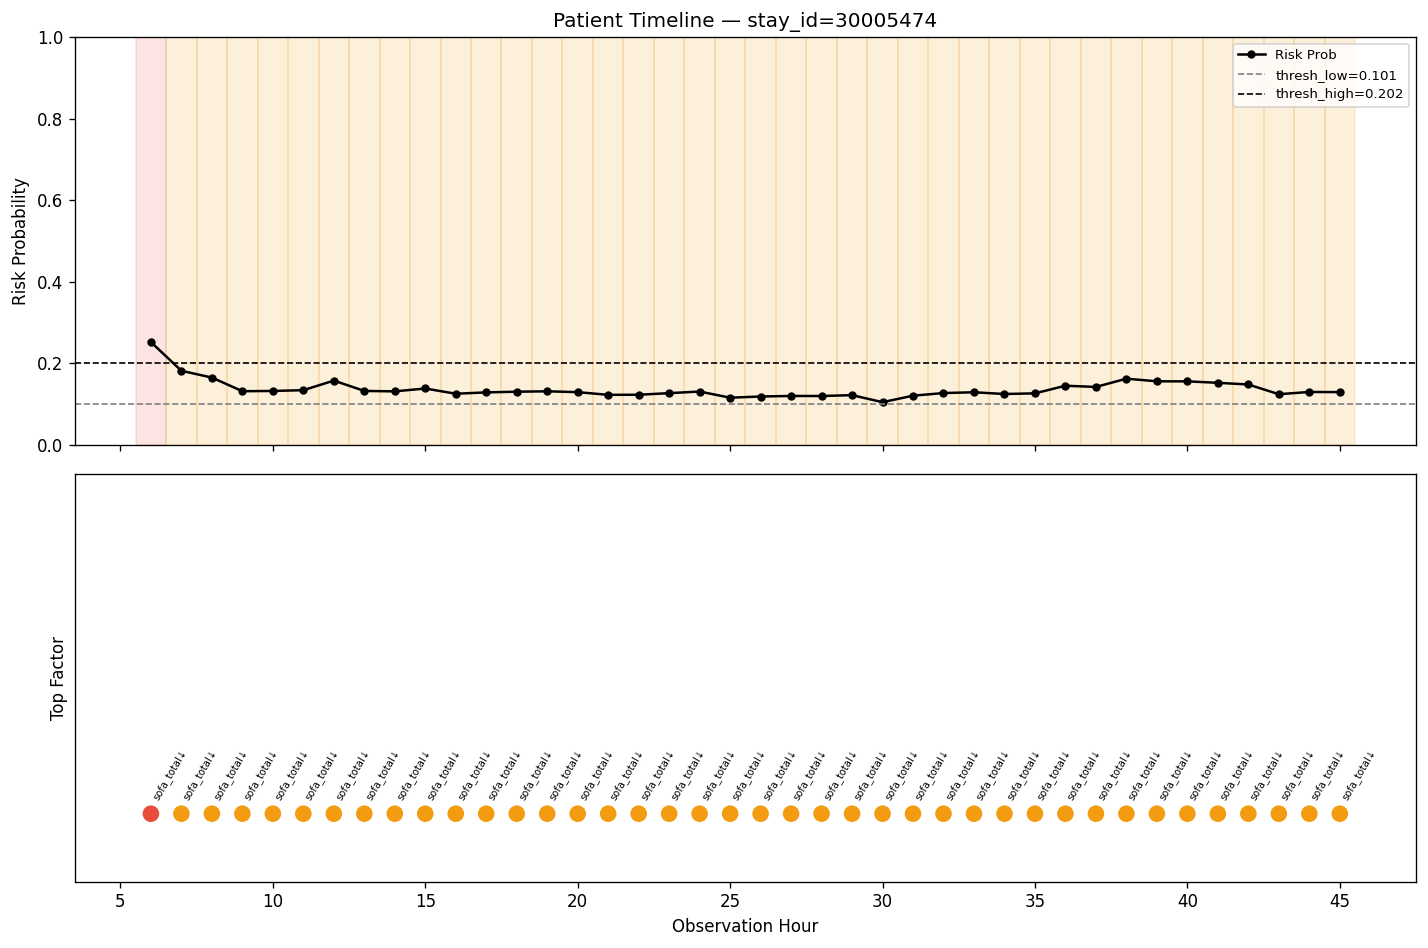


✔ 단일 환자 타임라인 테스트 완료


In [12]:
print('Step 3: 동작 테스트 — 단일 환자')

# 엔진 초기화
engine = SepsisRiskEngine(
    model_path     = MODEL_DIR     / 'xgb_final_models.pkl',
    feature_path   = PROCESSED_DIR / 'xgb_model_features.csv',
    threshold_path = PROCESSED_DIR / 'risk_thresholds.csv',
    median_path    = PROCESSED_DIR / 'feature_medians.csv',
)

# High 등급 환자 선택 (risk_scored.csv 기준)
df_scored = pd.read_csv(PROCESSED_DIR / 'risk_scored.csv')
high_stays = df_scored[df_scored['risk_level'] == 'High']['stay_id'].unique()
if len(high_stays) == 0:
    raise ValueError('High 등급 환자가 없습니다. Threshold를 확인하세요.')

test_stay_id = high_stays[0]
print(f'\n테스트 환자: stay_id = {test_stay_id}')

# 시간별 추론
df_timeline = engine.predict_patient_timeline(test_stay_id, df_all)
print(f'타임라인 rows: {len(df_timeline)}')

# 핵심 컬럼만 출력
display_cols = ['stay_id', 'observation_hour', 'risk_prob', 'risk_level',
                'top1_feature', 'top1_direction', 'top2_feature', 'top2_direction']
display_cols = [c for c in display_cols if c in df_timeline.columns]
print(df_timeline[display_cols].to_string(index=False))

# ── 시각화: 시간별 위험 확률 꺾은선 ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

COLORS = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
hours = df_timeline['observation_hour'].values
probs = df_timeline['risk_prob'].values
levels= df_timeline['risk_level'].values

# 상단: 확률 꺾은선 + 등급 색상 배경
ax = axes[0]
ax.plot(hours, probs, 'k-o', markersize=4, linewidth=1.5, label='Risk Prob')
ax.axhline(engine.thresh_low,  color='gray',  linestyle='--', lw=1,
           label=f'thresh_low={engine.thresh_low:.3f}')
ax.axhline(engine.thresh_high, color='black', linestyle='--', lw=1,
           label=f'thresh_high={engine.thresh_high:.3f}')
# 등급별 배경색
for i, (h, lvl) in enumerate(zip(hours, levels)):
    ax.axvspan(h - 0.5, h + 0.5, alpha=0.15, color=COLORS[lvl])
ax.set_ylabel('Risk Probability')
ax.set_title(f'Patient Timeline — stay_id={test_stay_id}')
ax.legend(fontsize=8)
ax.set_ylim(0, 1)

# 하단: Top-1 피처 변화
ax2 = axes[1]
top1_feats = df_timeline['top1_feature'].values if 'top1_feature' in df_timeline.columns else ['N/A']*len(hours)
top1_dirs  = df_timeline['top1_direction'].values if 'top1_direction' in df_timeline.columns else ['']*len(hours)
labels = [f'{f}{d}' for f, d in zip(top1_feats, top1_dirs)]
ax2.scatter(hours, np.zeros(len(hours)), c=[COLORS[l] for l in levels], s=80, zorder=3)
for x, lbl in zip(hours, labels):
    ax2.text(x, 0.05, lbl, rotation=60, fontsize=6, ha='left', va='bottom')
ax2.set_xlabel('Observation Hour')
ax2.set_ylabel('Top Factor')
ax2.set_ylim(-0.3, 1.5)
ax2.set_yticks([])

plt.tight_layout()
plt.show()
print('\n✔ 단일 환자 타임라인 테스트 완료')


## Step 4: 배치 테스트 — 전체 데이터 & 13번 결과 일치율 확인

> `features_final.csv` 전체로 `predict_batch()` 실행.  
> 13번 결과(`risk_scored.csv`)와 위험 등급 일치율 ≥ 99% 기대.  
> (13번은 마지막 fold 모델만 사용, 14번은 앙상블 평균 → 약간의 차이 가능)


In [13]:
print('Step 4: 배치 테스트 — 전체 데이터')

t0 = time.time()
df_batch_result = engine.predict_batch(df_all)
elapsed = time.time() - t0

n_rows   = len(df_batch_result)
rows_per_sec = n_rows / elapsed

print(f'\n배치 추론 완료: {n_rows:,}행 / {elapsed:.2f}초 ({rows_per_sec:,.0f} 행/초)')
print(f'출력 shape: {df_batch_result.shape}')

# 13번 결과와 일치율 비교
if 'risk_level' in df_scored.columns:
    # stay_id + observation_hour 기준으로 병합
    merge_cols = ['stay_id', 'observation_hour']
    merge_cols = [c for c in merge_cols if c in df_scored.columns and c in df_batch_result.columns]
    df_compare = df_batch_result[merge_cols + ['risk_level']].rename(
        columns={'risk_level': 'level_14'})
    df_compare = df_compare.merge(
        df_scored[merge_cols + ['risk_level']].rename(columns={'risk_level': 'level_13'}),
        on=merge_cols, how='inner')
    match_rate = (df_compare['level_14'] == df_compare['level_13']).mean()
    print(f'\n=== 13번 vs 14번 등급 일치율 ===')
    print(f'  비교 행 수: {len(df_compare):,}')
    print(f'  일치율: {match_rate*100:.2f}%')
    if match_rate < 0.99:
        print('  [INFO] 앙상블 평균(14번) vs 마지막 fold(13번) 차이로 인한 불일치')
    else:
        print('  ✔ 99% 이상 일치 — 파이프라인 정상')

# 등급 분포 출력
print('\n=== 배치 결과 등급 분포 ===')
level_counts = df_batch_result['risk_level'].value_counts()
for lvl in ['Low', 'Medium', 'High']:
    cnt = level_counts.get(lvl, 0)
    pct = cnt / n_rows * 100
    print(f'  {lvl:6s}: {cnt:6,}개 ({pct:5.1f}%)')

print(f'\n✔ 배치 테스트 완료 ({rows_per_sec:,.0f} 행/초)')


Step 4: 배치 테스트 — 전체 데이터

배치 추론 완료: 158,985행 / 43.16초 (3,684 행/초)
출력 shape: (158985, 66)

=== 13번 vs 14번 등급 일치율 ===
  비교 행 수: 158,985
  일치율: 84.08%
  [INFO] 앙상블 평균(14번) vs 마지막 fold(13번) 차이로 인한 불일치

=== 배치 결과 등급 분포 ===
  Low   : 93,522개 ( 58.8%)
  Medium: 23,361개 ( 14.7%)
  High  : 42,102개 ( 26.5%)

✔ 배치 테스트 완료 (3,684 행/초)


## Step 5: 추론 파이프라인 저장

> `SepsisRiskEngine` 객체를 pickle로 저장합니다.  
> 로드 후 즉시 `.predict_single()` / `.predict_batch()` 호출 가능.


In [14]:
print('Step 5: 추론 파이프라인 저장')

engine_path = MODEL_DIR / 'risk_engine.pkl'
with open(engine_path, 'wb') as f:
    pickle.dump(engine, f)

# 파일 크기 확인
size_mb = engine_path.stat().st_size / (1024 ** 2)
print(f'✔ SepsisRiskEngine 저장 완료: {engine_path}')
print(f'   파일 크기: {size_mb:.1f} MB')

# 로드 테스트
with open(engine_path, 'rb') as f:
    engine_loaded = pickle.load(f)
print(f'\n✔ 로드 테스트 성공 (features: {len(engine_loaded.features)}개)')
print('사용법: engine.predict_single(feature_dict)')


Step 5: 추론 파이프라인 저장
✔ SepsisRiskEngine 저장 완료: DATA/models/risk_engine.pkl
   파일 크기: 6.5 MB

✔ 로드 테스트 성공 (features: 51개)
사용법: engine.predict_single(feature_dict)


## Step 6: 사용 예시 출력

> EMR 연동 시 실제 서비스에서 사용하는 코드 예시입니다.


In [15]:
print('Step 6: 사용 예시 출력')

# ── 실제 서비스 연동 예시 코드 출력 ────────────────────────────────────
example_code = '''
# ── 실제 서비스 연동 예시 ────────────────────────────────────────────────
import pickle
from pathlib import Path

# 1. 엔진 로드 (서버 시작 시 1회)
with open('../models/risk_engine.pkl', 'rb') as f:
    engine = pickle.load(f)

# 2. 새 환자 데이터 (EMR에서 매 시간 수집)
new_data = {
    'hr_mean'      : 112,
    'sbp'          : 88,
    'lactate_mean' : 3.2,
    'wbc_mean'     : 14.5,
    'temp_mean'    : 38.5,
    # ... 기타 피처 (없으면 학습 데이터 median으로 자동 대체)
}

# 3. 위험도 산출
result = engine.predict_single(new_data)
print(f'위험 등급: {result["risk_level"]}')
print(f'확률:     {result["risk_prob"]:.3f}')
print(f'조치:     {result["action_message"]}')
for i, factor in enumerate(result['top_factors'], 1):
    print(f'원인 {i}:  {factor["feature"]}{factor["direction"]} (SHAP={factor["shap"]:+.3f})')
'''
print(example_code)

# ── 실제 실행: features_final에서 랜덤 샘플 1행 ─────────────────────────
sample_row = df_all.sample(1, random_state=42).iloc[0]
sample_dict = {feat: sample_row[feat] for feat in selected_features if feat in sample_row.index}

print('─'*60)
print('실제 실행 결과 (features_final에서 랜덤 1행 선택):')
result = engine.predict_single(sample_dict)
print(f'  stay_id         : {int(sample_row["stay_id"]) if "stay_id" in sample_row.index else "N/A"}')
print(f'  observation_hour: {sample_row["observation_hour"] if "observation_hour" in sample_row.index else "N/A"}')
print(f'  위험 등급        : {result["risk_level"]}')
print(f'  확률             : {result["risk_prob"]:.4f}')
print(f'  조치             : {result["action_message"]}')
print('  주요 원인:')
for i, factor in enumerate(result['top_factors'], 1):
    print(f'    {i}. {factor["feature"]}{factor["direction"]}  SHAP={factor["shap"]:+.4f}')
print('─'*60)


Step 6: 사용 예시 출력

# ── 실제 서비스 연동 예시 ────────────────────────────────────────────────
import pickle
from pathlib import Path

# 1. 엔진 로드 (서버 시작 시 1회)
with open('../models/risk_engine.pkl', 'rb') as f:
    engine = pickle.load(f)

# 2. 새 환자 데이터 (EMR에서 매 시간 수집)
new_data = {
    'hr_mean'      : 112,
    'sbp'          : 88,
    'lactate_mean' : 3.2,
    'wbc_mean'     : 14.5,
    'temp_mean'    : 38.5,
    # ... 기타 피처 (없으면 학습 데이터 median으로 자동 대체)
}

# 3. 위험도 산출
result = engine.predict_single(new_data)
print(f'위험 등급: {result["risk_level"]}')
print(f'확률:     {result["risk_prob"]:.3f}')
print(f'조치:     {result["action_message"]}')
for i, factor in enumerate(result['top_factors'], 1):
    print(f'원인 {i}:  {factor["feature"]}{factor["direction"]} (SHAP={factor["shap"]:+.3f})')

────────────────────────────────────────────────────────────
실제 실행 결과 (features_final에서 랜덤 1행 선택):
  stay_id         : 39600195
  observation_hour: 8.0
  위험 등급        : High
  확률             : 0.9671
  조치             : 즉

## Step 7: 최종 성능 요약 & 파일 목록 확인


In [16]:
print('Step 7: 최종 성능 요약')

print('\n' + '='*60)
print('=== 14. Inference Pipeline 완료 ===')
print('='*60)

print('\n[저장된 파일]')
files_to_check = [
    MODEL_DIR     / 'xgb_final_models.pkl',
    MODEL_DIR     / 'risk_engine.pkl',
    PROCESSED_DIR / 'xgb_selected_features.csv',
    PROCESSED_DIR / 'risk_thresholds.csv',
    PROCESSED_DIR / 'risk_scored.csv',
    PROCESSED_DIR / 'feature_medians.csv',
]
for fp in files_to_check:
    fp = Path(fp)
    if fp.exists():
        size_kb = fp.stat().st_size / 1024
        print(f'  ✔ {fp.name:<40s} ({size_kb:8.1f} KB)')
    else:
        print(f'  ✗ {fp.name:<40s} 미존재')

print('\n[엔진 사양]')
print(f'  모델 Fold 수  : {len(engine.models)}')
print(f'  사용 피처 수  : {len(engine.features)}')
print(f'  thresh_low   : {engine.thresh_low:.4f}')
print(f'  thresh_high  : {engine.thresh_high:.4f}')

print(f'\n[배치 추론 속도]')
print(f'  {rows_per_sec:,.0f} 행/초 (전체 {n_rows:,}행 기준)')
print('='*60)

print('\n✔ 14. Inference Pipeline 완료')


Step 7: 최종 성능 요약

=== 14. Inference Pipeline 완료 ===

[저장된 파일]
  ✔ xgb_final_models.pkl                     (  3781.9 KB)
  ✔ risk_engine.pkl                          (  6675.7 KB)
  ✔ xgb_selected_features.csv                (     0.3 KB)
  ✔ risk_thresholds.csv                      (     0.1 KB)
  ✔ risk_scored.csv                          ( 14967.7 KB)
  ✔ feature_medians.csv                      (     0.8 KB)

[엔진 사양]
  모델 Fold 수  : 5
  사용 피처 수  : 51
  thresh_low   : 0.1009
  thresh_high  : 0.2018

[배치 추론 속도]
  3,684 행/초 (전체 158,985행 기준)

✔ 14. Inference Pipeline 완료
